# Regresión Logística de Connect-4

En este ejercicio usamos el siguiente dataset: https://archive.ics.uci.edu/dataset/26/connect+4. Se creará un modelo de regresión logística para predecir el resultado final de una partida de Connect-4. Suponga que está diseñando un sistema inteligente para analizar posiciones estratégicas en juegos de tablero y desea determinar las posibilidades de victoria del primer jugador en función del estado actual de las casillas. Disponemos de un dataset histórico con posiciones legales del juego tras 8 movimientos.

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Preprocesamiento de Datos
Incluiremos la librería pandas ya que los datos del dataset son caractéres. Los pandas nos ayudarán a tener un mejor manejo de estos datos

In [91]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Libreria para manipulación y análisis de datos tabulares
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

Para cada ejemplo de entrenamiento, se cuenta con la configuración de las fichas en el tablero (42 características seleccionadas) y el resultado final de la partida (victoria, derrota o empate). Por lo que, crearemos un modelo de clasificación que calcule la probabilidad de que una configuración específica del tablero resulte en una victoria para el jugador que inició la partida.

La siguiente celda cargará los datos y las etiquetas correspondientes:



In [92]:
# Cargar datos
# Las primeras columnas contienen las fichas en el tablero
# contiene la etiqueta que indica el resultado final de la partida
df = pd.read_csv('/content/drive/MyDrive/SIS420/connect-4.csv', header=None)
print(df.info())
m = y.size
print(m)
# imprimimos cantidad de características
n = X.shape[1]
print(n)
#Convertimos las letras en números
df.replace({'x': 1, 'o': -1, 'b': 0, 'win': 1, 'loss': 0, 'draw': 0}, inplace=True)
# Convertir a matriz de Numpy
data = df.values.astype(float)


X = data[:, 0:42] #desde la primera columna hasta la penúltima
y = data[:, 42] #la última columna es la que hay que predecir

print(X)
print(y)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67557 entries, 0 to 67556
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       67557 non-null  object
 1   1       67557 non-null  object
 2   2       67557 non-null  object
 3   3       67557 non-null  object
 4   4       67557 non-null  object
 5   5       67557 non-null  object
 6   6       67557 non-null  object
 7   7       67557 non-null  object
 8   8       67557 non-null  object
 9   9       67557 non-null  object
 10  10      67557 non-null  object
 11  11      67557 non-null  object
 12  12      67557 non-null  object
 13  13      67557 non-null  object
 14  14      67557 non-null  object
 15  15      67557 non-null  object
 16  16      67557 non-null  object
 17  17      67557 non-null  object
 18  18      67557 non-null  object
 19  19      67557 non-null  object
 20  20      67557 non-null  object
 21  21      67557 non-null  object
 22  22      67557 non-null

/tmp/ipykernel_726/67720100.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'x': 1, 'o': -1, 'b': 0, 'win': 1, 'loss': 0, 'draw': 0}, inplace=True)


Como podemos observar contamos con 67557 instancias, por lo que, dividiremos el dataset manualmente (80% entrenamiento, 20% prueba), para probar la efectividad con datos que el modelo no ha visto.

### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, visualizaremos los datos. El dataset de Connect-4 se compone de variables discretas o categóricas. Cada casilla del tablero solo puede tomar tres valores posibles: $1$ (Jugador X), $-1$ (Jugador O) o $0$ (Vacío). Mostramos los datos de 2 casillas en una gráfica bidimensional llamando a la función `plotData`.

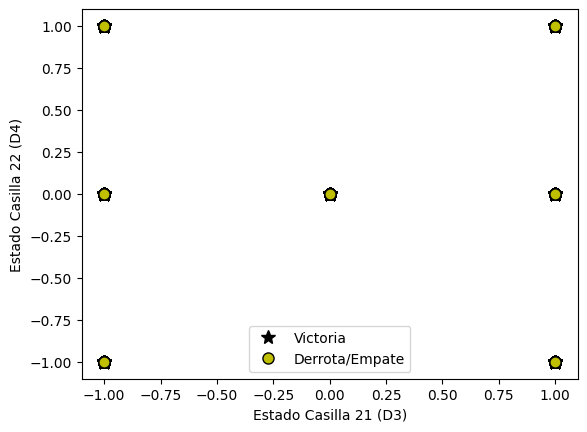

In [93]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para las partidas ganadas y
    # o para las partidas perdidas.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Determina indices de positivos y negativos
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 20], X[pos, 21], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 20], X[neg, 21], 'ko', mfc='y', ms=8, mec='k', mew=1)

plotData(X, y)
# adiciona etiquetas para los ejes
pyplot.xlabel('Estado Casilla 21 (D3)')
pyplot.ylabel('Estado Casilla 22 (D4)')
pyplot.legend(['Victoria', 'Derrota/Empate'])
pass


Observamos que los puntos se agrupan en una cuadrícula de $3 \times 3$ coordenadas posibles basadas en las coordenadas ($-1, 0, 1$). Esta superposición indica que miles de partidas comparten estados idénticos en esas posiciones del tablero. Sin embargo, se muestra que solo 7 espacios de los 9 llegan a ser utilizados, ya que si la casilla de abajo está vacía, la casilla de arriba también.

### 1.2 Implementacion

#### 1.2.1 Función Sigmoidea

La hipotesis para la regresión logistica es:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea actúa como un "embudo". Toma cualquier valor numérico ($z$) y lo aplasta para que siempre esté en el rango de 0 a 1, mapea predicciones a probabilidades se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5.

In [94]:
def sigmoid(z):
    # Calculamos la sigmoide de una entrada z
    # convierte la entrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [95]:
# Prueba la implementacion de la función sigmoidea
z = [-3, 0, 2]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-3, 0, 2] ) =  [0.04742587 0.5        0.88079708]


La prueba muestra que cuando da la evalución es 0, la función sigmoidea devuelve un resultado de 0.5 que significa que el modelo está indeciso por el 50% de probabilidad de ganar, cuando es positivo tiene una probabilidad más alta de victoria (88%) y cuando es negativo probabilidad más baja de victoria (4%).

### 1.2.2 Función de Costo y Gradiente
Se implementa la funcion costo y gradiente, para la regresión logistica. Pero antes es importante agregar el termino de intercepcion a X.

In [96]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
print(m)
print(n)
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

67557
42


In [97]:
m_entren = int(0.8 * m)
X_entren, X_prueba = X[:m_entren], X[m_entren:]
y_entren, y_prueba = y[:m_entren], y[m_entren:]


print(f"Ejemplos de entrenamiento: {X_entren.shape[0]}")
print(f"Ejemplos de prueba: {X_prueba.shape[0]}")
print(f"Número de características (n): {n}")

Ejemplos de entrenamiento: 54045
Ejemplos de prueba: 13512
Número de características (n): 42


Introducimos la función de costo para medir el error de la predicción.



In [98]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

Y la función de Descenso por el gradiente que es diferente a la regresión lineal porque tienen diferentes definiciones de $h_\theta(x)$.

In [99]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0] #cantidad de datos de entrenamiento
    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []
    p_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
        # Evaluación de la precisión
        # Calculamos la predicción (0 o 1) con los thetas de ESTA iteración
        p_actual = np.round(sigmoid(X.dot(theta.T)))

        # Contamos cuántas 'y' inferidas son exactamente iguales a las 'y' reales
        aciertos = np.sum(p_actual == y)

        # Sacamos el porcentaje y lo guardamos en el historial
        porcentaje_aciertos = (aciertos / m) * 100
        p_history.append(porcentaje_aciertos)
    return theta, J_history, p_history

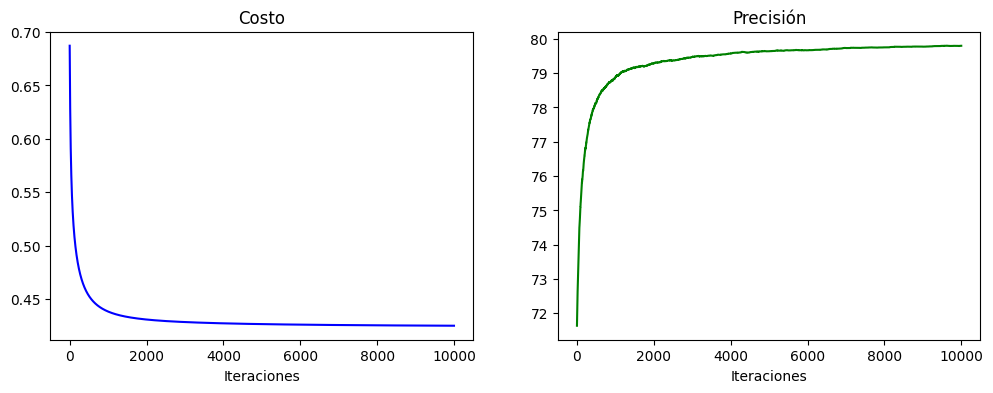

Probabilidad de victoria: 0.9164
Resultado real en el dataset: Victoria


In [104]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.1
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_entren.shape[1])
theta, J_history, p_history = descensoGradiente(theta, X_entren, y_entren, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(12, 4))
pyplot.subplot(1, 2, 1)
pyplot.plot(J_history, color='blue')
pyplot.title('Costo')
pyplot.xlabel('Iteraciones')

pyplot.subplot(1, 2, 2)
pyplot.plot(p_history, color='green')
pyplot.title('Precisión')
pyplot.xlabel('Iteraciones')
pyplot.show()

# verificar si tiene posibilidad de ganar
fila=55000
X_array = X[fila, :]
res_real = y[fila]

resultado_predicho = sigmoid(np.dot(X_array, theta))

print('Probabilidad de victoria: {:.4f}'.format(resultado_predicho))
print(f'Resultado real en el dataset: {"Victoria" if res_real == 1 else "Derrota/Empate"}')


In [101]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

Testeamos la función, coparamos con 0.693 porque  $-\ln(0.5) \approx 0.693$, esto valida nuestra función y se demuestra que esta procesando bien el costo

In [102]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(X.shape[1])
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad.shape)
print('Gradiente en theta inicial (zeros):')
#mostramos solo los primeros 5 valores
print('\t[{:.4f}, {:.4f}, {:.4f}, {:.4f}, {:.4f}, ...]'.format(*grad[:5]))

Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

(43,)
Gradiente en theta inicial (zeros):
	[-0.1583, 0.0653, 0.0299, 0.0065, -0.0003, ...]


### 1.2.3 Parámetros de aprendizaje usando `scipy.optimize`
En lugar de utilizar un descenso por el gradiente con tasa de aprendizaje fija, empleamos la librería `scipy.optimize.minimize`, se usa el algoritmo de Newton Truncado (TNC) que es muy eficiente para datasets con muchas características (como las 42 posiciones del tablero) ya que ajusta dinámicamente el tamaño del paso.

In [103]:
# Establecer las opciones para optimize.minimize
options= {'maxiter': 1000}

# revisar la documentacion de scipy's optimize.minimize para mayor descripcion de los parametros
# La funcion devuekve un objeto `OptimizeResult`
# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_entren, y_entren),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por `OptimizeResult`
# contiene el valor del costFunction de un theta optimizado
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

# Imprimir resultados adaptados a Connect-4
print('Costo final optimizado por TNC: {:.3f}'.format(cost))
print('Theta optimizado (primeros 5 valores para evitar error de dimensiones):')
# Usamos [:5] para que quepan en los espacios y no lance error
print('\t[{:.3f}, {:.3f}, {:.3f}, {:.3f}, {:.3f}, ...]'.format(*theta[:5]))

/tmp/ipykernel_726/2041523388.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


Costo final optimizado por TNC: 0.424
Theta optimizado (primeros 5 valores para evitar error de dimensiones):
	[1.099, -0.753, -0.586, -0.511, -0.336, ...]
